### Step 1: Import API keys and libraries

In [1]:
import os
import json
import gradio as gr
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import Markdown, display


load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise Exception("API_KEY is missing.")

/workspaces/AIchallenge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2-6: Simple RAG with chunking and embedding with chromadb
Note: the embedding aren't OpenAI embeddings.

In [2]:
from pathlib import Path
import chromadb
from document_chunker import DocumentChunker

# 1. Load the documents (every .txt sitting next to this script)
filenames = sorted(Path(".").glob("*.txt"))
docs = [(p.read_text(), {"source": p.name}) for p in filenames]

# 2. Chunk them all into one flat list, metadata preserved per chunk
chunker = DocumentChunker(chunk_size=800, chunk_overlap=100)
all_chunks = chunker.split_many(docs)

# 3. Store in Chroma (lets Chroma embed with its default model)
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_or_create_collection(name="documents")

In [3]:
# Assign deterministic UUIDs to each chunk based on source document and chunk index, so we can upsert without creating duplicates
import uuid

### You can change the namespace to any fixed UUID, but if you do, you'll need to clear the collection to avoid duplicates, since the same chunk will get a different UUID with a different namespace. So we use a fixed namespace and keep it constant to allow upserts without duplicates.  See the following quoted code for how to mint a namespace if you want to use a different one.

"""
# Run this ONCE, in a throwaway cell, to mint your namespace:
import uuid
print(uuid.uuid4())
"""

NAMESPACE = uuid.NAMESPACE_DNS   # any fixed namespace works; just keep it constant

collection.upsert(
    ids=[
        str(uuid.uuid5(NAMESPACE, f"{c.metadata['source']}::{c.metadata['chunk_index']}"))
        for c in all_chunks
    ],
    documents=[c.text for c in all_chunks],
    metadatas=[c.metadata for c in all_chunks],
)

print(f"{len(all_chunks)} chunks from {len(filenames)} documents")
print(f"collection now holds {collection.count()} chunks")

2026-05-28 16:22:30.388421947 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


70 chunks from 3 documents
collection now holds 140 chunks


In [ ]:
### Use this code only if your collection has duplicates and you want to remove them; it deletes all but one chunk per source document
"""client.delete_collection("documents")"""
# then re-ingest with the new namespace

'client.delete_collection("documents")'

In [4]:
# Verify the metadata is correct and preserved and count chunks per source document
import chromadb
from collections import Counter

client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_or_create_collection(name="documents")

meta = collection.get(include=["metadatas"])["metadatas"]
print(Counter(m["source"] for m in meta))

Counter({'document_netflix_culture.txt': 94, 'document_2025_annual_report_intro.txt': 38, 'document_work_life_philosophy.txt': 8})


### Step 6: Test Retrieval

In [5]:
test_query = "days off"
test_query2 = "teamwork and collaboration"

queries = [test_query, test_query2]

results = collection.query(
    query_texts=[test_query, test_query2],
    n_results=3,
)

for q_idx, query in enumerate(queries):
    print(f"Query: {query}")
    print("Retrieved Chunks:")
    docs = results["documents"][q_idx]
    metas = results["metadatas"][q_idx]
    for doc, meta in zip(docs, metas):
        print(f"[{meta['source']}] chunk {meta['chunk_index']}:\n{doc}\n")
    print("-" * 60)

Query: days off
Retrieved Chunks:
[document_work_life_philosophy.txt] chunk 0:
Based on the text provided, here is the plain text summary of Netflix’s supportive benefits and workplace policies designed to help employees do their best work.Work-Life Balance & Time AwayFlexible Time Away: There is no prescribed 9-to-5 workday or set holiday schedule. Salaried employees take the time they need when their mind and body require a break.Parental Leave: The policy is simply to "take care of your child and yourself." Employees decide how much time they need in consultation with their manager and talent partners.Intermixed Time: Work and personal time are frequently blended, allowing individuals to observe what is personally important to them.Health & Family SupportFamily Forming: Global benefits support preservation, fertility, surrogacy, and adoption options. 

[document_work_life_philosophy.txt] chunk 0:
Based on the text provided, here is the plain text summary of Netflix’s supportive bene

### Cluster visualization

In [6]:
# Venv sanity check: use %pip for installing packages in notebooks, and check sys.executable to confirm the notebook is using the expected Python environment
import sys
print(sys.executable)

/workspaces/AIchallenge/.venv/bin/python


Cluster 0: Corporate Financial Outlook and Risk Disclosure
Cluster 1: Building and sustaining a high-performance team
Cluster 2: Core Workplace Values and Principles


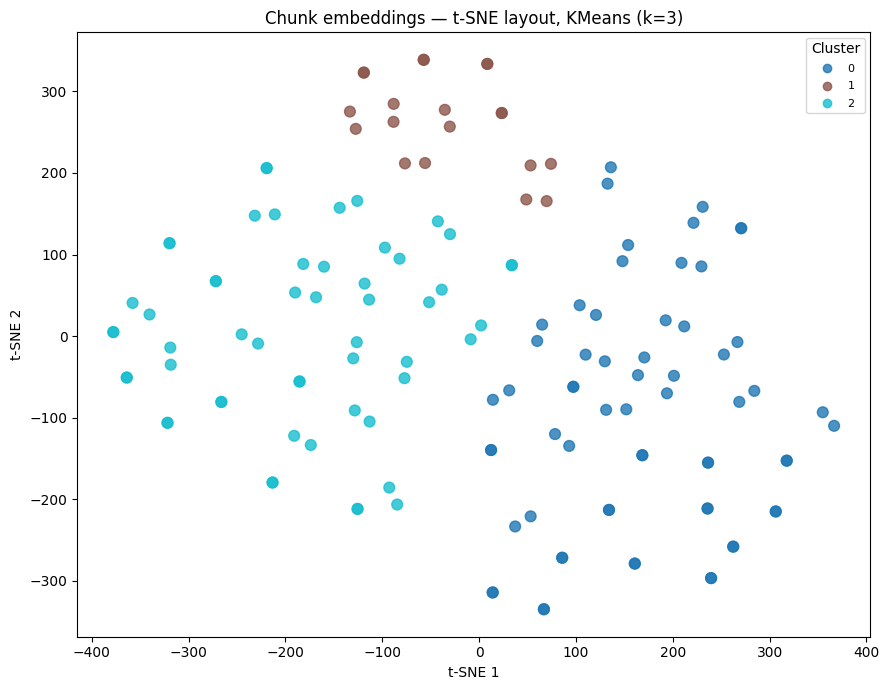

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ---- adjustable knob ----
n_clusters = 3          # <- change this to set the number of clusters
# -------------------------

# 1. Pull embeddings out of Chroma (must request them explicitly)
data = collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(data["embeddings"])           # (70, 384)
sources = [m["source"] for m in data["metadatas"]]

# 2. KMeans on the ORIGINAL high-dim embeddings
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

# 3. t-SNE down to 2-D purely for plotting
coords = TSNE(
    n_components=2,
    perplexity=15,        # must be < number of points
    random_state=42,
    init="pca",
).fit_transform(embeddings)

# 4. Scatter, colored by KMeans cluster
plt.figure(figsize=(9, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=labels, cmap="tab10", alpha=0.8, s=60)
plt.legend(*scatter.legend_elements(), title="Cluster", fontsize=8)
plt.title(f"Chunk embeddings — t-SNE layout, KMeans (k={n_clusters})")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout()
#plt.show()

# Plotly hover labels
import plotly.express as px

fig = px.scatter(
    x=coords[:, 0], y=coords[:, 1],
    color=labels.astype(str),
    hover_data={
        "id": data["ids"],
        "chunk_index": [m["chunk_index"] for m in data["metadatas"]],
        "source": [m["source"] for m in data["metadatas"]],
    },
    title="Chunk embeddings (hover for id)",
)
fig.update_traces(marker=dict(size=9, opacity=0.8))
fig.show()

# Describe each cluster by the most common source document among its chunks using a prompt to GPT-4.1-mini
data = collection.get(include=["embeddings", "documents", "metadatas"])
embeddings = np.array(data["embeddings"])
docs = data["documents"]
labels = kmeans.fit_predict(embeddings) 


client = OpenAI(api_key=OPENAI_API_KEY)

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

k = labels.max() + 1

# Pool each cluster's chunks into one "super-document"
for c in range(k):
    sample = [d for d, lab in zip(docs, labels) if lab == c][:5]
    prompt = ("Give a short 5–8 word label for the common theme of these excerpts:\n\n"
              + "\n---\n".join(sample))
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    print(f"Cluster {c}: {resp.choices[0].message.content}")

### Step 7: Function to Process the Conversation Turn (with RAG)

In [ ]:
system_message = "You are a helpful assistant. that answers questions based on the provided context.\
    If you don't know the answer, just say that you don't know.  Always use all available information\
        to provide the best answer possible."

In [ ]:
client = OpenAI(api_key=OPENAI_API_KEY)   # define once, outside the function

def respond_ai(message, history):
    # RAG retrieval — Chroma embeds the query with the same default model
    results = collection.query(
        query_texts=[message],
        n_results=3,
    )

    docs = results["documents"][0]
    metas = results["metadatas"][0]
    context = "\n---\n".join(
        f"[{m['source']}] {d}" for d, m in zip(docs, metas)
    )

    system_message_enhanced = system_message + "\n\nContext:\n" + context

    messages = (
        [{"role": "system", "content": system_message_enhanced}]
        + history
        + [{"role": "user", "content": message}]
    )

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
    )

    return response.choices[0].message.content
    
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages
    )
    
    reply = response.choices[0].message.content
    return reply

In [ ]:
gr.ChatInterface(fn=respond_ai).launch(inbrowser=True, inline=False)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
